# EDA — Fraud_Data.csv (E-commerce Transactions)

**Task 1 · Adey Innovations Fraud Detection**

This notebook covers:
1. Data loading & cleaning
2. Exploratory data analysis (univariate + bivariate)
3. Geolocation enrichment (IP → Country)
4. Class imbalance quantification


In [6]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from data_loader import load_fraud_data, load_ip_country, clean_fraud_data, merge_ip_country
from eda_utils   import (plot_class_imbalance, plot_numeric_distributions,
                          plot_categorical_fraud_rate, plot_correlation_heatmap,
                          plot_country_fraud)

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Imports OK')
print(load_fraud_data)


Imports OK
<function load_fraud_data at 0x0000017452BC53A0>


## 1. Load Data

In [7]:
DATA_DIR = '../data'

df_raw =load_fraud_data(f'{DATA_DIR}/raw/Fraud_Data.csv')
df_ip  = load_ip_country(f'{DATA_DIR}/raw/IpAddress_to_Country.csv')

print(df_raw.shape)
df_raw.head(3)



INFO | Fraud_Data loaded: 151112 rows, 11 cols
INFO | IP-Country table loaded: 138846 rows


(151112, 11)


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1


In [ ]:
print(df_raw.dtypes)
print("also the second one")
print(df_raw.describe(include='all').T)


user_id                    int64
signup_time       datetime64[ns]
purchase_time     datetime64[ns]
purchase_value             int64
device_id                 object
source                    object
browser                   object
sex                       object
age                        int64
ip_address               float64
class                      int64
dtype: object
also the second one
                   count  unique            top   freq  \
user_id         151112.0     NaN            NaN    NaN   
signup_time       151112     NaN            NaN    NaN   
purchase_time     151112     NaN            NaN    NaN   
purchase_value  151112.0     NaN            NaN    NaN   
device_id         151112  137956  CQTUVBYIWWWBC     20   
source            151112       3            SEO  60615   
browser           151112       5         Chrome  61432   
sex               151112       2              M  88293   
age             151112.0     NaN            NaN    NaN   
ip_address      151112.

NameError: name 'LogisticRegression' is not defined

## 2. Data Cleaning

In [9]:
# ── Missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({'missing_count': missing, 'missing_%': missing_pct})
print("Missing values:\n", missing_report[missing_report['missing_count'] > 0])

# ── Duplicates
n_dups = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {n_dups}")


Missing values:
 Empty DataFrame
Columns: [missing_count, missing_%]
Index: []

Duplicate rows: 0


In [12]:
df = clean_fraud_data(df_raw)
print(f"Rows after cleaning: {len(df):,}  (removed {len(df_raw)-len(df):,})")


INFO | Dropped 0 duplicate rows
INFO | Clean Fraud_Data: 151112 rows remain


Rows after cleaning: 151,112  (removed 0)


## 3. Class Imbalance

INFO | Dropped 0 duplicate rows
INFO | Clean Fraud_Data: 151112 rows remain


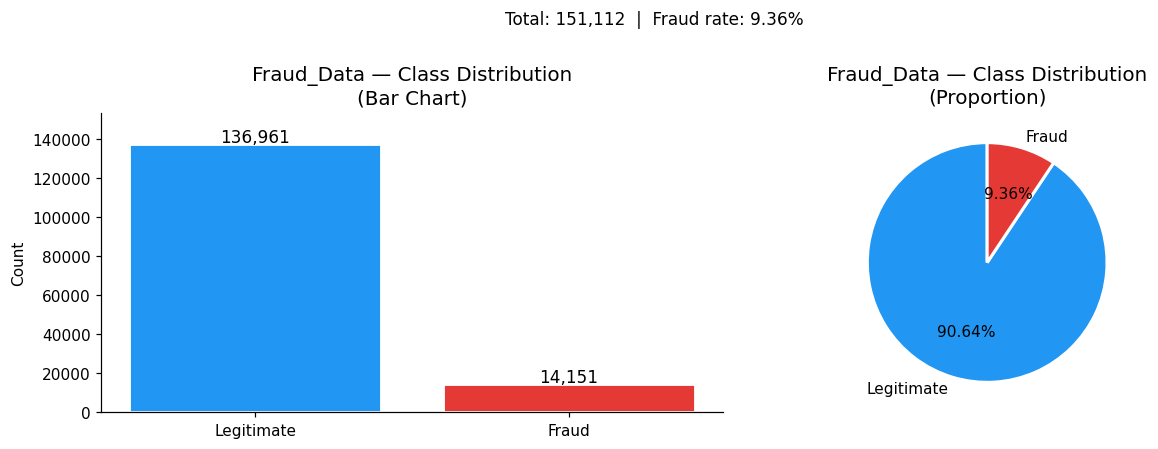

Legitimate: 136,961  |  Fraud: 14,151
Fraud rate: 9.36%  →  Severely imbalanced dataset

Consequence: accuracy alone is misleading; we use AUC-PR and F1.


In [13]:
df = clean_fraud_data(df_raw)
plot_class_imbalance(df['class'], title='Fraud_Data — Class Distribution')

counts = df['class'].value_counts().sort_index()
print(f"Legitimate: {counts[0]:,}  |  Fraud: {counts[1]:,}")
print(f"Fraud rate: {df['class'].mean()*100:.2f}%  →  Severely imbalanced dataset")
print("\nConsequence: accuracy alone is misleading; we use AUC-PR and F1.")



## 4. Univariate Analysis

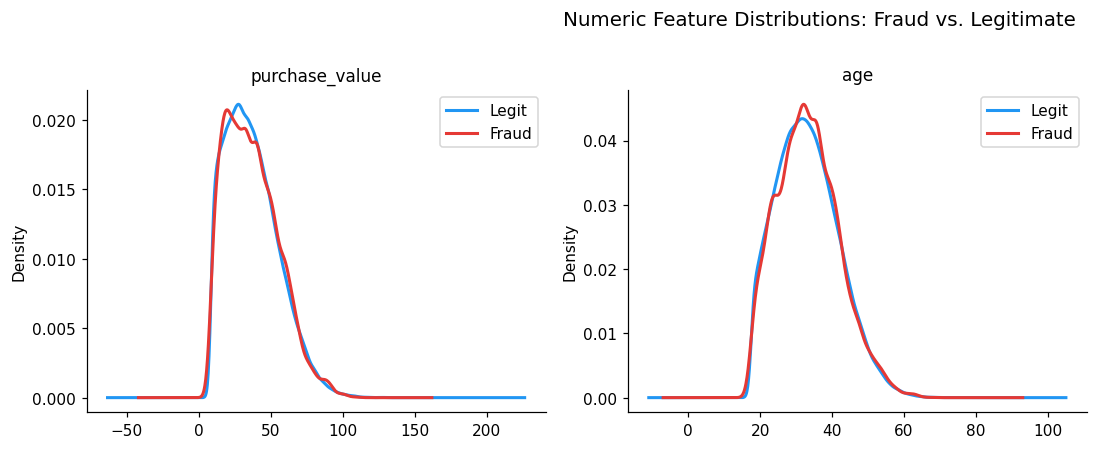

In [14]:
NUM_COLS = ['purchase_value', 'age']
plot_numeric_distributions(df, NUM_COLS, target='class')


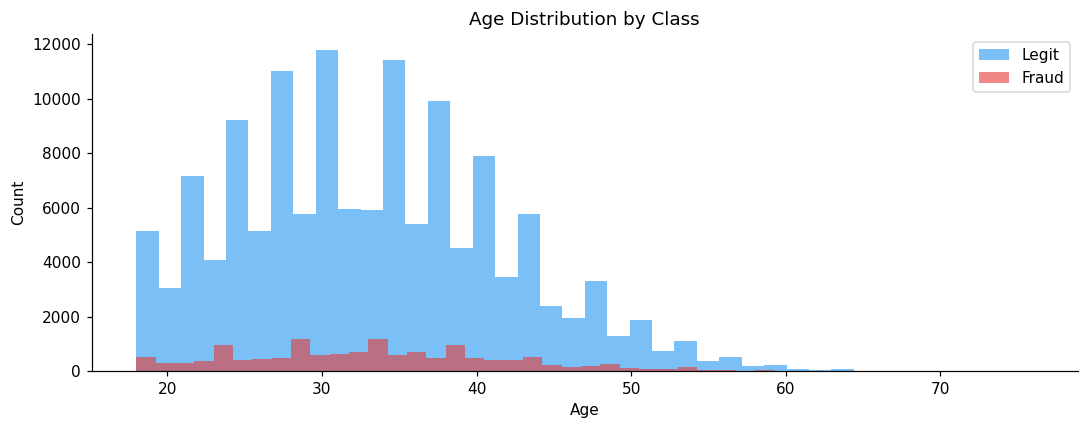

Key observation: Younger users (18-30) show higher fraud concentration.


In [15]:
# Age distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df[df['class']==0]['age'], bins=40, color='#2196F3', alpha=0.6, label='Legit')
ax.hist(df[df['class']==1]['age'], bins=40, color='#E53935', alpha=0.6, label='Fraud')
ax.set_xlabel('Age')
ax.set_ylabel('Count')
ax.set_title('Age Distribution by Class')
ax.legend()
plt.tight_layout()
plt.show()

print("Key observation: Younger users (18-30) show higher fraud concentration.")


## 5. Categorical Features vs Fraud Rate

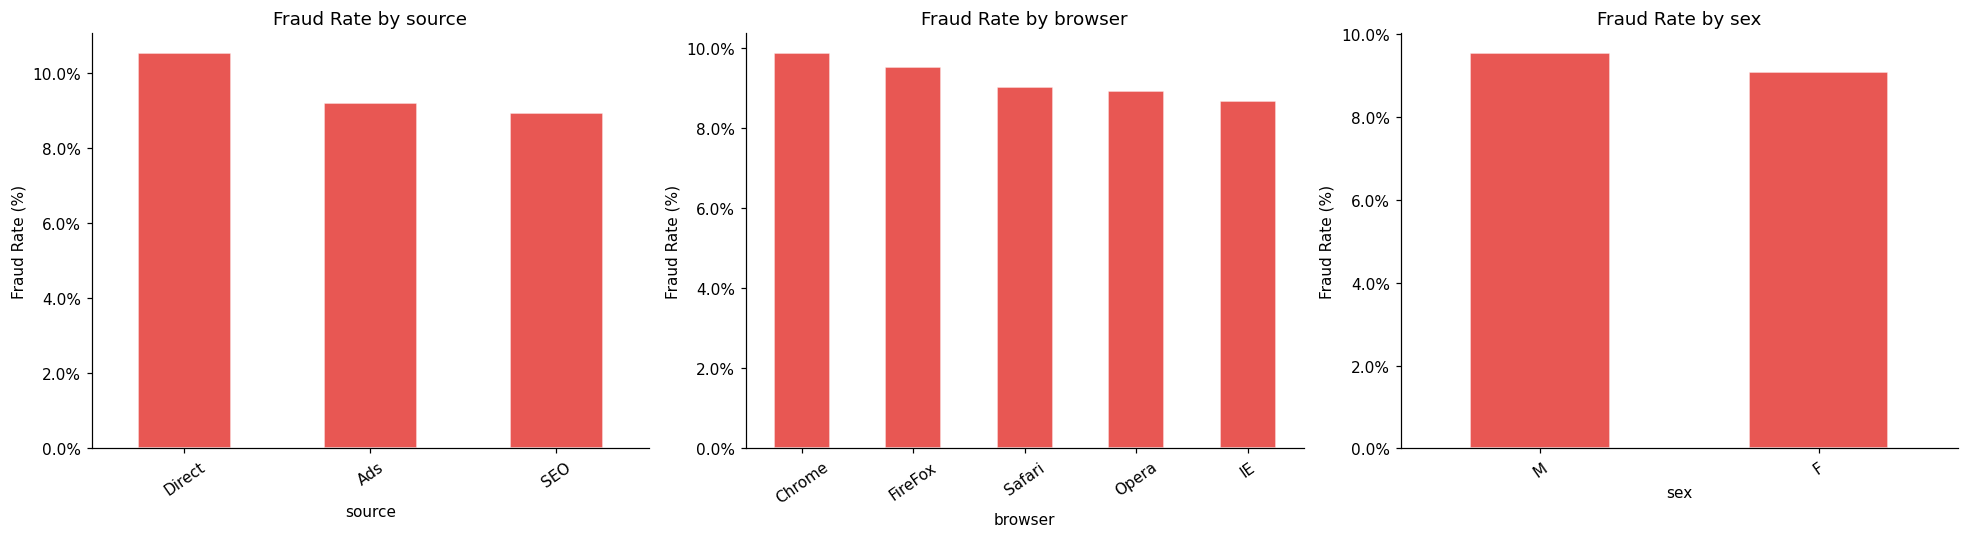

In [17]:
plot_categorical_fraud_rate(df, ['source', 'browser', 'sex'], target='class')


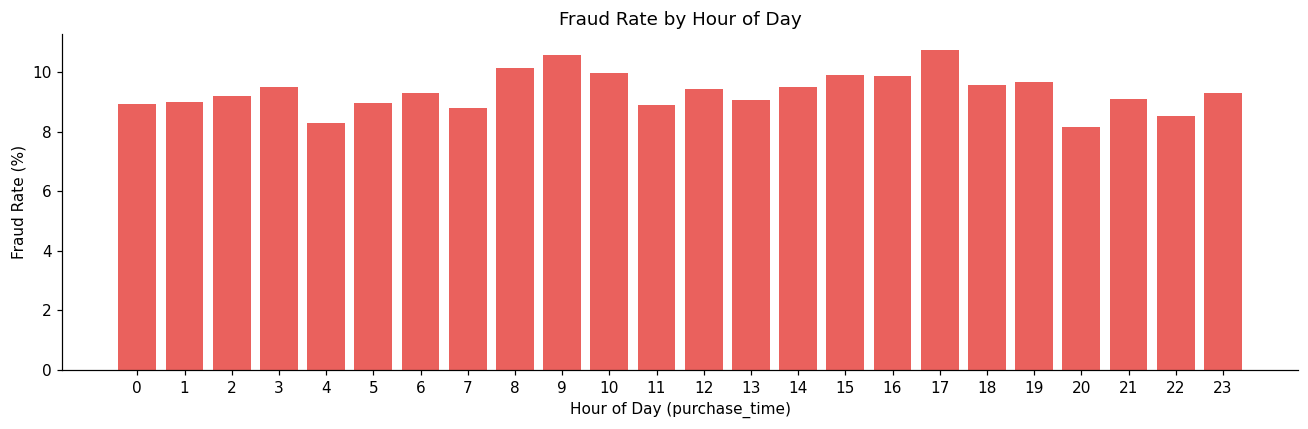

Peak fraud hour: 17:00  (10.7% fraud rate)


In [16]:
# Time-of-day signal (purchase_time hour)
df['hour_of_day'] = df['purchase_time'].dt.hour
hourly_fraud = df.groupby('hour_of_day')['class'].mean() * 100

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly_fraud.index, hourly_fraud.values, color='#E53935', alpha=0.8)
ax.set_xlabel('Hour of Day (purchase_time)')
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Hour of Day')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

peak_hour = hourly_fraud.idxmax()
print(f"Peak fraud hour: {peak_hour}:00  ({hourly_fraud[peak_hour]:.1f}% fraud rate)")


## 6. Geolocation Enrichment (IP → Country)

In [18]:
# The IpAddress_to_Country file uses plain numeric IP bounds
# Fraud_Data ip_address column is also stored as a float (numeric)
# So we use the float value directly — no dotted-decimal conversion needed.

df_merged = merge_ip_country(df, df_ip)

mapped_pct = (df_merged['country'] != 'Unknown').mean() * 100
print(f"Successfully mapped: {mapped_pct:.1f}% of transactions to a country")
print(df_merged['country'].value_counts().head(10))


INFO | IP-country merge: 129146/151112 rows mapped


Successfully mapped: 85.5% of transactions to a country
country
United States        58049
Unknown              21966
China                12038
Japan                 7306
United Kingdom        4490
Korea Republic of     4162
Germany               3646
France                3161
Canada                2975
Brazil                2961
Name: count, dtype: int64


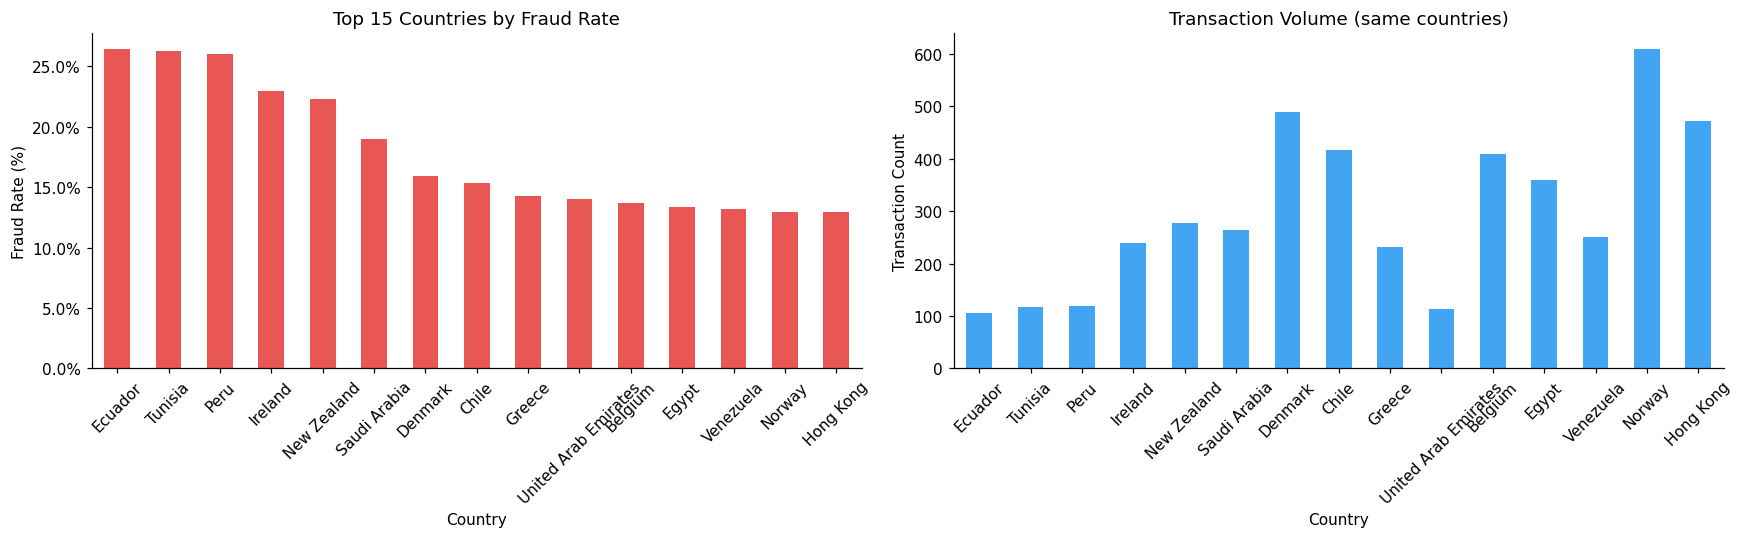

In [19]:
plot_country_fraud(df_merged, target='class', min_txns=100)


In [20]:
# Country-level summary table
country_stats = (
    df_merged.groupby('country')['class']
    .agg(fraud_rate='mean', transactions='count')
    .assign(fraud_rate=lambda x: (x['fraud_rate'] * 100).round(2))
    .query('transactions >= 50')
    .sort_values('fraud_rate', ascending=False)
)
print(country_stats.head(20).to_string())


                      fraud_rate  transactions
country                                       
Luxembourg                 38.89            72
Ecuador                    26.42           106
Tunisia                    26.27           118
Peru                       26.05           119
Bolivia                    24.53            53
Kuwait                     23.33            90
Ireland                    22.92           240
New Zealand                22.30           278
Lithuania                  18.95            95
Saudi Arabia               18.94           264
Denmark                    15.92           490
Chile                      15.35           417
Greece                     14.29           231
United Arab Emirates       14.04           114
Belgium                    13.69           409
Egypt                      13.37           359
Costa Rica                 13.33            90
Venezuela                  13.15           251
Norway                     12.97           609
Hong Kong    

## 7. Bivariate Analysis

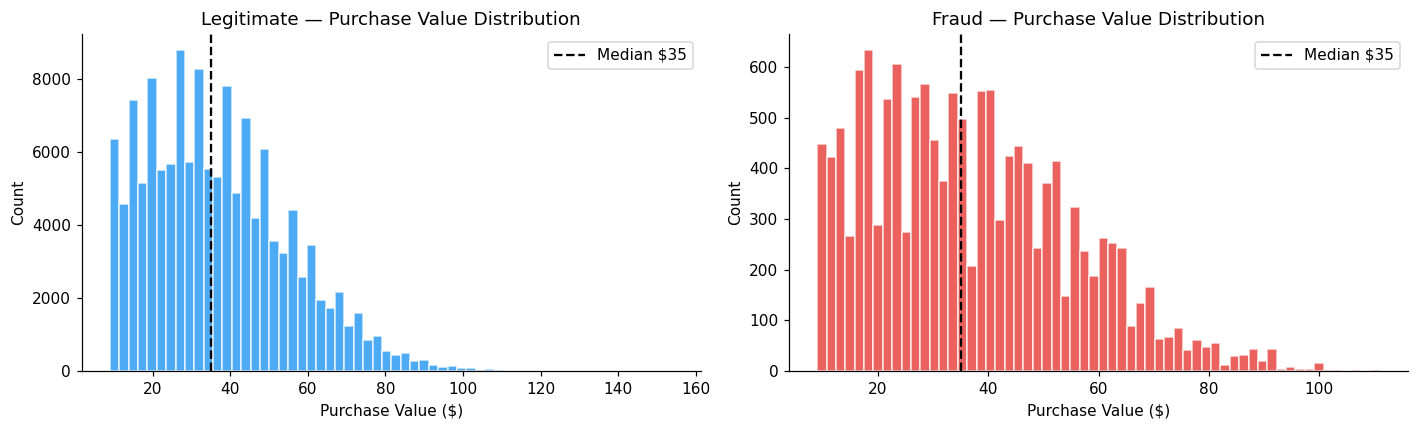

Fraud median purchase: $35.00
Legit median purchase: $35.00


In [21]:
# Purchase value vs fraud
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cls, label, color in [
    (axes[0], 0, 'Legitimate', '#2196F3'),
    (axes[1], 1, 'Fraud',      '#E53935'),
]:
    vals = df[df['class'] == cls]['purchase_value']
    ax.hist(vals, bins=60, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label} — Purchase Value Distribution')
    ax.set_xlabel('Purchase Value ($)')
    ax.set_ylabel('Count')
    ax.axvline(vals.median(), color='black', linestyle='--', label=f'Median ${vals.median():.0f}')
    ax.legend()
plt.tight_layout()
plt.show()

print("Fraud median purchase: ${:.2f}".format(df[df['class']==1]['purchase_value'].median()))
print("Legit median purchase: ${:.2f}".format(df[df['class']==0]['purchase_value'].median()))


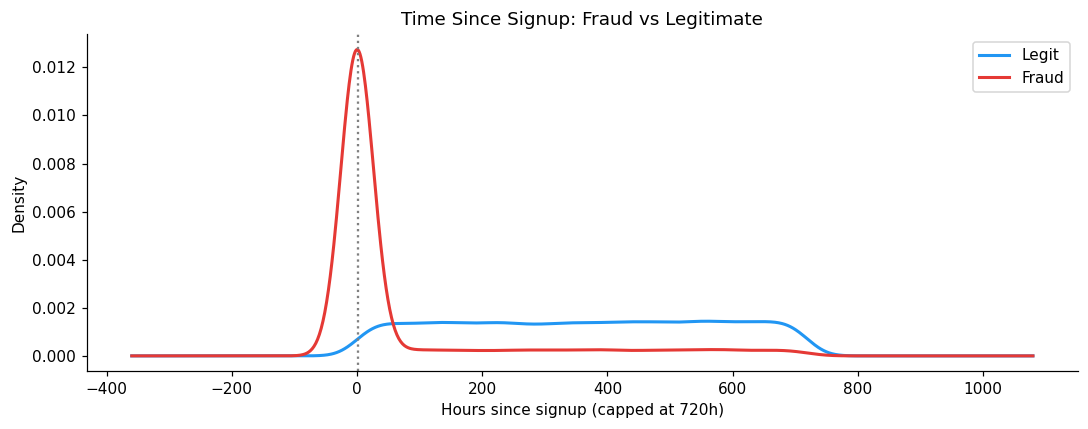

Fraud transactions within 1 hour of signup: 53.7%


In [22]:
# time_since_signup_h vs fraud
df_merged['time_since_signup_h'] = (
    (df_merged['purchase_time'] - df_merged['signup_time']).dt.total_seconds() / 3600
)

fig, ax = plt.subplots(figsize=(10, 4))
for cls, label, color in [(0, 'Legit', '#2196F3'), (1, 'Fraud', '#E53935')]:
    subset = df_merged[df_merged['class'] == cls]['time_since_signup_h']
    subset = subset[subset <= 720]  # cap at 30 days for readability
    subset.plot.kde(ax=ax, label=label, color=color, linewidth=2)
ax.set_xlabel('Hours since signup (capped at 720h)')
ax.set_title('Time Since Signup: Fraud vs Legitimate')
ax.legend()
ax.axvline(1, color='gray', linestyle=':', label='1-hour mark')
plt.tight_layout()
plt.show()

fraud_under1h = (
    df_merged[df_merged['class']==1]['time_since_signup_h'] < 1
).mean() * 100
print(f"Fraud transactions within 1 hour of signup: {fraud_under1h:.1f}%")


## 8. Save Cleaned + Enriched Data

In [23]:
os.makedirs('../data/processed', exist_ok=True)

df_merged.to_csv('../data/processed/fraud_data_clean.csv', index=False)
print("Saved: data/processed/fraud_data_clean.csv")
print(f"Shape: {df_merged.shape}")
print("\nColumns:", list(df_merged.columns))


Saved: data/processed/fraud_data_clean.csv
Shape: (151112, 17)

Columns: ['user_id', 'signup_time', 'purchase_time', 'purchase_value', 'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class', 'hour_of_day', 'ip_int', 'lower_int', 'upper_int', 'country', 'time_since_signup_h']


## 9. EDA Summary

| Finding | Implication |
|---|---|
| Fraud rate ≈ 9.4% | Severely imbalanced — use AUC-PR / F1, apply SMOTE |
| Fraud spikes within 1h of signup | `time_since_signup_h` is a strong feature |
| Late-night hours (00:00–02:00) show elevated fraud | `hour_of_day` is useful |
| Certain browsers/sources have higher fraud rates | Encode and include in model |
| Country-level variation is significant | IP-country enrichment adds signal |
